# Phase 8 - Class-conditioned bubble selector

**Goal**: implement and apply a new bubble selector that uses the K-means cluster + Markov tables to make rhythm-aware decisions.

**Score formula**:
```
selection_score = w1 * markov_score
                + w2 * burst_score
                + w3 * size_score
                + w4 * instrument_variety_score
                - w5 * regularity_penalty
```

Plute a hard quota rule: at most Y selections in any X-second window.

We apply this selector offline to the recorded data to produce `df_markov_selected` for evaluation.

## 0. Setup

In [1]:
import os
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DATA_CLEAN_DIR = '../data_clean'
df = pd.read_csv(os.path.join(DATA_CLEAN_DIR, 'all_events_sml.csv'))
df = df.sort_values('t_rel').reset_index(drop=True)

with open(os.path.join(DATA_CLEAN_DIR, 'markov_models.pkl'), 'rb') as f:
    markov_data = pickle.load(f)
markov_models = markov_data['markov_models']
label_map = markov_data['label_map']

print(f'Events: {len(df):,}')
print(f'Clusters: {sorted(markov_models.keys())}')


Events: 4,312
Clusters: [0, 1, 2, 3]


## 8.1 Score component functions

In [2]:
def interval_to_sml(dt, s_thr=0.25, m_thr=0.80):
    if dt < s_thr:  return 'S'
    if dt < m_thr:  return 'M'
    return 'L'

def get_markov_score(markov_models, cluster_id, last_symbol, candidate_symbol):
    return markov_models[cluster_id].get(last_symbol, {}).get(candidate_symbol, 0.0)

def compute_burst_score(density_1s, density_10s, eps=1e-6):
    recent = density_1s / 1.0
    longer = density_10s / 10.0
    raw = recent / (longer + eps)
    return min(raw, 5.0) / 5.0

def compute_size_score(current_area, reference_areas):
    if len(reference_areas) == 0:
        return 0.5
    num_smaller = (np.asarray(reference_areas) <= current_area).sum()
    return num_smaller / len(reference_areas)

def compute_instrument_variety_score(current_group, last_selected_group, n_same_group_3s):
    group_change = 1.0 if current_group != last_selected_group else 0.0
    norm_same = min(n_same_group_3s, 3) / 3.0
    same_var = 1.0 - norm_same
    return 0.5 * group_change + 0.5 * same_var

def compute_regularity_penalty(candidate_interval, last_10_intervals):
    if len(last_10_intervals) < 10:
        return 0.0
    arr = np.asarray(last_10_intervals)
    mean_iei = arr.mean()
    if mean_iei == 0:
        return 0.0
    cv_10 = arr.std() / mean_iei
    similarity = abs(candidate_interval - mean_iei) / mean_iei
    if cv_10 < 0.10 and similarity < 0.15:
        return 1.0
    return 0.0

def selected_count_in_window(selected_times, current_time, X):
    return sum(1 for t in selected_times if current_time - X <= t < current_time)

## 8.2 Run the selector offline

I think score weights are very important - let me start with the fixed number first and come back after evaluation

In [3]:
# Hyperparameters
X_SEC = 1.5     # quota window (seconds)
Y_MAX = 3       # max selections in window

# Score weights
W_MARKOV     = 2.0
W_BURST      = 1.5
W_SIZE       = 0.5
W_VARIETY    = 0.5
W_REGULARITY = 1.5

# Decision threshold per cluster (tune this)
# Higher threshold = fewer selections
threshold_by_cluster = {c: 1.4 for c in markov_models.keys()}

# Reference areas: use a calibration buffer of recent events
REF_BUFFER_SIZE = 200

# State variables that update as we scan events
selected_times      = []
selected_intervals  = []
last_selected_time  = None
last_selected_sym   = None
last_selected_group = None
reference_areas     = []

# We need cluster_id, density_1s, density_10s, n_same_group_3s for each event.
# These were computed in Phase 4. Make sure they're available.
required_cols = ['cluster', 'density_1s', 'density_10s', 'n_same_group_3s', 'group', 'area']
for col in required_cols:
    assert col in df.columns, f'Missing column: {col}'

print(f'Running selector on {len(df):,} events...')
results = []
for i, ev in df.iterrows():
    t_now = ev['t_rel']
    cluster_id = int(ev['cluster'])
    
    # Update reference areas (rolling buffer)
    reference_areas.append(ev['area'])
    if len(reference_areas) > REF_BUFFER_SIZE:
        reference_areas.pop(0)
    
    # 1. Hard quota check
    if selected_count_in_window(selected_times, t_now, X_SEC) >= Y_MAX:
        results.append(False)
        continue
    
    # 2. Markov score
    if last_selected_time is None:
        candidate_interval = None
        candidate_symbol = 'L'
        markov_score = 0.5
        regularity_penalty = 0.0
    else:
        candidate_interval = t_now - last_selected_time
        candidate_symbol = interval_to_sml(candidate_interval)
        markov_score = get_markov_score(markov_models, cluster_id,
                                         last_selected_sym, candidate_symbol)
        regularity_penalty = compute_regularity_penalty(
            candidate_interval, selected_intervals[-10:]
        )
    
    # 3. Other components
    burst_score = compute_burst_score(ev['density_1s'], ev['density_10s'])
    size_score  = compute_size_score(ev['area'], reference_areas[:-1])  # exclude self
    iv_score    = compute_instrument_variety_score(
                    ev['group'], last_selected_group, ev['n_same_group_3s'])
    
    # 4. Combine
    selection_score = (
        W_MARKOV * markov_score
        + W_BURST * burst_score
        + W_SIZE * size_score
        + W_VARIETY * iv_score
        - W_REGULARITY * regularity_penalty
    )
    
    # 5. Decide
    threshold = threshold_by_cluster[cluster_id]
    select = selection_score > threshold
    results.append(select)
    
    if select:
        selected_times.append(t_now)
        if candidate_interval is not None:
            selected_intervals.append(candidate_interval)
        last_selected_time = t_now
        last_selected_sym = candidate_symbol
        last_selected_group = ev['group']

df['selected_markov'] = results
print(f'\nResults:')
print(f'  Total events       : {len(df):,}')
print(f'  Markov selected    : {sum(results):,}')
print(f'  Current rule sel.  : {(df["selected"]==1).sum():,}')

Running selector on 4,312 events...

Results:
  Total events       : 4,312
  Markov selected    : 2,430
  Current rule sel.  : 2,238


## 8.3 Compare selectors visually

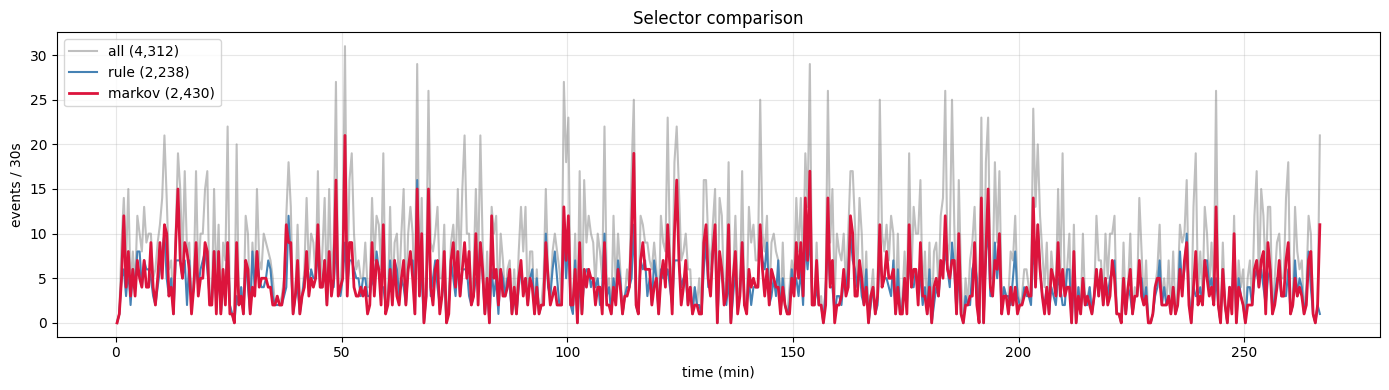

In [4]:
# Density comparison
bin_sec = 30
edges = np.arange(0, df['t_rel'].max() + bin_sec, bin_sec)
h_all,    _ = np.histogram(df['t_rel'], bins=edges)
h_rule,   _ = np.histogram(df[df['selected']==1]['t_rel'], bins=edges)
h_markov, _ = np.histogram(df[df['selected_markov']]['t_rel'], bins=edges)
centers_min = (edges[:-1] + edges[1:]) / 2 / 60.0

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(centers_min, h_all,    label=f'all ({len(df):,})',    color='gray', alpha=0.5)
ax.plot(centers_min, h_rule,   label=f'rule ({(df["selected"]==1).sum():,})',
        color='steelblue', lw=1.5)
ax.plot(centers_min, h_markov, label=f'markov ({sum(results):,})',
        color='crimson', lw=2)
ax.set_xlabel('time (min)'); ax.set_ylabel(f'events / {bin_sec}s')
ax.set_title('Selector comparison')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('../outputs/plots/21_selector_comparison.png', dpi=120)
plt.show()

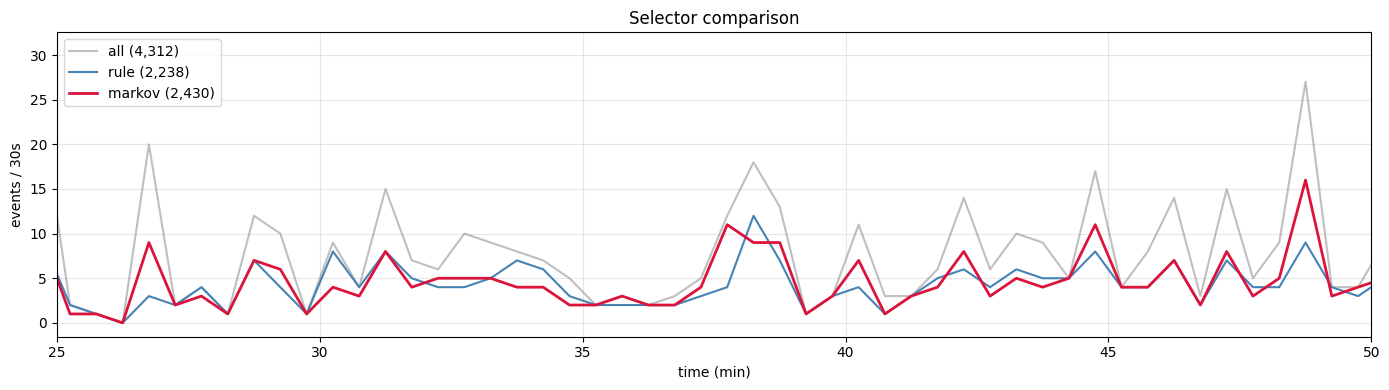

In [5]:
# Density comparison
bin_sec = 30
edges = np.arange(0, df['t_rel'].max() + bin_sec, bin_sec)
h_all,    _ = np.histogram(df['t_rel'], bins=edges)
h_rule,   _ = np.histogram(df[df['selected']==1]['t_rel'], bins=edges)
h_markov, _ = np.histogram(df[df['selected_markov']]['t_rel'], bins=edges)
centers_min = (edges[:-1] + edges[1:]) / 2 / 60.0

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(centers_min, h_all,    label=f'all ({len(df):,})',    color='gray', alpha=0.5)
ax.plot(centers_min, h_rule,   label=f'rule ({(df["selected"]==1).sum():,})',
        color='steelblue', lw=1.5)
ax.plot(centers_min, h_markov, label=f'markov ({sum(results):,})',
        color='crimson', lw=2)
ax.set_xlim(25,50)
ax.set_xlabel('time (min)'); ax.set_ylabel(f'events / {bin_sec}s')
ax.set_title('Selector comparison')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('../outputs/plots/21_selector_comparison_25-50.png', dpi=120)
plt.show()

### Findings
It seems that markov based model pick different events from the rule-based model. 
<br> Good news is, the shape looks similar to all for markov-based model, so let's evaluate in the next phase!

## 8.4 Save

In [6]:
out = os.path.join(DATA_CLEAN_DIR, 'all_events_with_markov.csv')
df.to_csv(out, index=False)
print(f'Saved: {out}')
print(f'New column: selected_markov (bool)')

Saved: ../data_clean/all_events_with_markov.csv
New column: selected_markov (bool)
